# EOS database demo: testing first pull request

Here, I (Artem) am testing whether the addition made by D. Rice is compatible with the database architecture.

## 1. Loading stuff

All the code (database class, routine to load data, routines to filter/manipulate data, and plotting routines) is hidden in the `./modules` folder.

In [1]:
from modules.eosdatabase import EOSDatabase
from modules.functions import *

Read all the available thermo data. It will go through all sub-folders to find all files that end with `_thermo.dat`. It will also read the metadata contained in each corresponding `_thermo.toml` file, and it will load that data into the python object. The point is: **developpers add more files, users just need to give the path to the folder**.

Description of EOS stuff is in [Section 5](#section_eos). 

In [2]:
database = EOSDatabase("./data")

Loaded: data/solomatovacaracas2021/solomatovacaracas2021_pyrolite_thermo.dat
Loaded: data/fischer2011/fischer2011_b8feo_thermo.dat
Loaded: data/fischer2011/fischer2011_b1feo_thermo.dat
Loaded: data/miozzi2020/miozzi2020_hcpfe-lowP_thermo.dat
Loaded: data/miozzi2020/miozzi2020_hcpfe-highP_thermo.dat
Loaded: data/caracas2024/caracas2024_pyrolite_thermo.dat
Loaded: data/hakim2018/hakim2018_hcpfe_thermo.dat


## 2. Printing stuff

I created a little script to easily print the summary of the database that has been loaded. This script is entirely customisable by developpers. Again: **developpers add features, users access the data easily**.

In [3]:
database.summary_thermo()

EOSDatabase summary thermo
--------------------------
Rows   : 564
Columns: 28
--------------------------
caracas2024 (NaCa2Al3Fe4Mg30Si24O65)
fischer2011 (FeO)
hakim2018 (Fe)
miozzi2020 (Fe)
solomatovacaracas2021 (NaCa2Al3Fe4Mg30Si24O65)


*For developpers*: all the data is just a giant pandas dataframe. If you are more familiar with pandas dataframes, you can just use them instead.

In [4]:
import pandas as pd
dataframe = database.df_thermo
# print the available keys of the dataframe
print(dataframe.keys())
# print just the P-rho-T-citation info
print(dataframe[["P[GPa]","rho[g/cm^3]","T[K]","entry"]])

Index(['V[Angstroms^3]', 'rho[g/cm^3]', 'P[GPa]', 'Pst.dev.[GPa]', 'T[K]',
       'Tst.dev.[K]', 'unique_id', 'science_material', 'science_formula',
       'science_phase', 'science_method', 'data_delimiter', 'label', 'entry',
       'rho[kg/m^3]', 'drho[kg/m^3]', 'V[m^3/mol]', 'dV[m^3/mol]', 'P[Pa]',
       'dP[Pa]', 'dT[K]', 'c/a', 'dc/a', 'science_cristal', 'other_notes',
       'MDsteps', 'dP[GPa]', 'U[kJ/kg]'],
      dtype='object')
            P[GPa]  rho[g/cm^3]     T[K]                           entry
0        36.200000     4.040000  1994.22  solomatovacaracas2021_pyrolite
1        19.420000     3.530000  1995.31  solomatovacaracas2021_pyrolite
2         8.720000     3.110000  1994.66  solomatovacaracas2021_pyrolite
3         3.110000     2.750000  1995.34  solomatovacaracas2021_pyrolite
4        -0.420000     2.440000  1999.77  solomatovacaracas2021_pyrolite
..             ...          ...      ...                             ...
559  121630.849640   105.886608   300.00       

## 3. Manipulating the database

Here are a few "methods" (python routines) that I vibe-wrote to manipulate the database object. For example, one method prints all the species that exist in the table (material, formula, source).

In [5]:
database.print_species_thermo()

Species in thermo database
--------------------------

iron
  - Fe : hakim2018
  - Fe : miozzi2020

pyrolite
  - NaCa2Al3Fe4Mg30Si24O65 : caracas2024
  - NaCa2Al3Fe4Mg30Si24O65 : solomatovacaracas2021

wustite
  - FeO : fischer2011


Filtering to keep only the wustite database

In [ ]:
db_wustite = database.filter_out(
    field="science_material",
    contains="wustite",
)

db_wustite.print_species_thermo()

Species in thermo database
--------------------------

wustite
  - FeO : fischer2011


## 4. Outputs: plots and writing to file

Probably one of the most important features of this catalog: be able to write all the data into a file. Again, I went ahead and defined a script making it very easy to do.

In [7]:
db_wustite.export_tsv(filename="thermo_wustite")


Export complete
File: output/thermo_wustite_20260616.tsv
Rows exported: 63


Plotting the filtered database of wustite

Found 2 entries


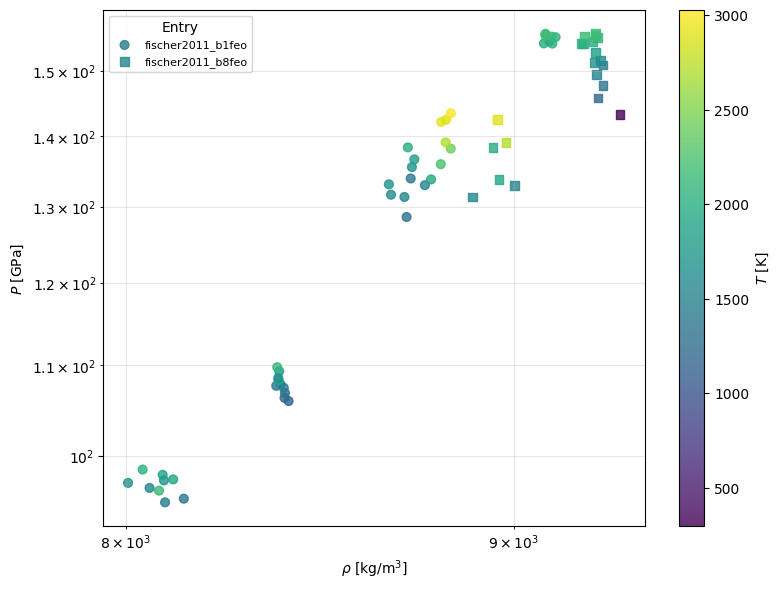

In [8]:
db_wustite.plot_rhopt()

Here I'm just playing around with the plot to make it look nicer. It's really powerful that the entire plot object is just passed to the main program and you can manipulate it however you want...

Found 2 entries


(0.0, 500.0)

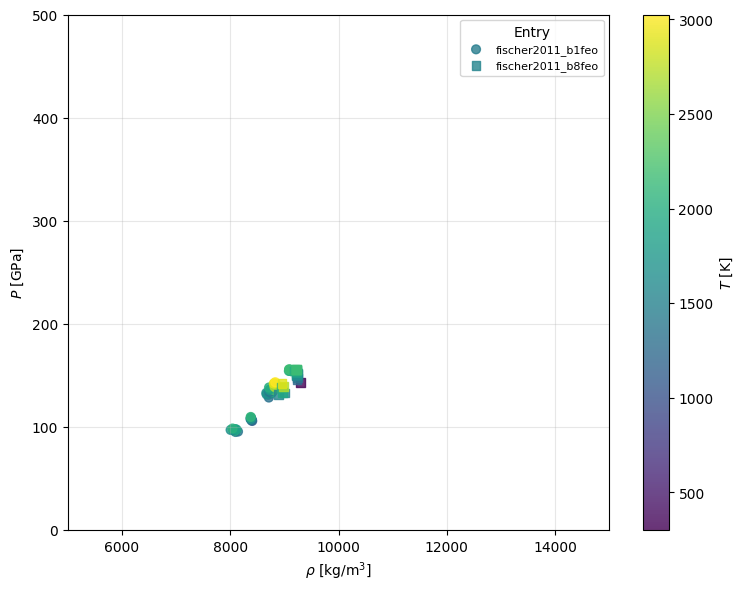

In [9]:
import matplotlib.pyplot as plt
db_wustite.plot_rhopt(plt_show=False)
plt.xscale('linear')
plt.yscale('linear')
plt.xlim(5e3,15e3) #x-axis in kg/m^3
plt.ylim(0,500) #y-axis in GPa

# 5. Loading EOS and extracting (experimental) <a id='section_eos'></a>

We can applyt the same methodology to EOSs. With the same framework, the EOSs were already loaded earlier.

We can define some methods to print summary of available EOS.

In [10]:
database.summary_eos()

EOSDatabase summary eos
-----------------------
Rows   : 3
Columns: 34
-----------------------
fischer2011 (FeO)
miozzi2020 (Fe)


In [11]:
database.print_species_eos()

Species in eos database
-----------------------

iron
  - Fe : miozzi2020

wustite
  - FeO : fischer2011


If we want to work with just one EOS of interest, it's a good idea to extract it from the full catalog. First, search for available entries, then get that entry.

In [12]:
print(database.df_eos["entry"])

0    fischer2011_b1feo
1    fischer2011_b8feo
2     miozzi2020_hcpfe
Name: entry, dtype: object


In [13]:
fischer_B1FeO_eos = database.get_eos(entry="fischer2011_b1feo")

And then use the existing functions to get information from that EOS.

In [14]:
print_science(fischer_B1FeO_eos)


Science of entry:  fischer2011_b1feo
-------
material: wustite
formula: FeO
phase: solid
cristal: B1
method: LH-DAC XRD


In [15]:
print_description(fischer_B1FeO_eos)


Description of entry:  fischer2011_b1feo
-----------
type: fit
cold_type: bm3
thermal_exist: True
thermal_type: debye
reference_temperature: 300


In [16]:
print_validity(fischer_B1FeO_eos)


Validity of entry:  fischer2011_b1feo
--------
min_p: 95.2153318933
max_p: 155.982534269
min_t: 1143.9
max_t: 3024.73
min_rho: 8.00561090858
max_rho: 9.11471886257


In [17]:
print_parameters(fischer_B1FeO_eos)

Parameters of entry:  fischer2011_b1feo
----------
V_0: 12.256
rho_0: 5.86194516971
K_0: 149.4
dK_0: 1.0
K_0_prime: 3.6
dK_0_prime: 0.04
T_0: 300
theta_0: 417.0
gamma_0: 1.41
dgamma_0: 0.05
q_debye: 0.5
